# 💳 Определение популярности геолокации для размещения банкомата

Исходная постановка задачи была представлена на соревновании по анализу данных [«Happy Data Year»](https://boosters.pro/championship/rosbank2/data). \
В качестве основы были использованы исходные данные о местах установки банкоматов, дополнительно обогащённые информацией о плотности населения, а также сведениями о других объектах, расположенных рядом в поределенном радиусе (магазинах, автобусных остановках, других банкоматах и прочем), полученные посредством базы данных **Open Street Map**.

In [1]:
from IPython.display import Image

display(Image(url='https://img.freepik.com/premium-vector/atm-machines-cash-machine-isometric-vector-illustration_163786-643.jpg', 
              width = 800)) 

## Cодержание <a class="anchor" id="content"></a>

* [1. Информация о Датасете](#first-bullet)

* [2. Импорт библиотек и загрузка данных](#second-bullet)

* [3. Обзор данных](#third-bullet)

* [Выводы](#conclusion)

## Разведочный анализ данных 

### 1. Информация о датасете <a class="anchor" id="first-bullet"></a>

В обучающей выборке находятся данные о геопозиции шести тысяч банкоматов Росбанка и его партнеров, а также целевая переменная — индекс популярности банкомата. В тестовой выборке еще две с половиной тысячи банкоматов, разделенных поровну на публичную и приватную часть.

 № |Cтолбец    | Расшифровка |
---|-----------|:-------:    |
1  |id        |   Уникальный номер банкомата |
2  |atm_group        |   Идентификатор банка, которому принадлежит банкомат |
3  |address         |   Адрес в формате хранения в системах банка |
4  |address_rus     |адрес восстановленный по данным поля address |
5  |lat       |широта локации address_rus |
6  |long        |долгота локации address_rus |
7  |target    |Результаты ЭКГ в состоянии покоя |

### 2. Импорт библиотек и загрузка данных <a class="anchor" id="second-bullet"></a>

In [2]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [12]:
df = pd.read_csv('/Users/anastasia/Downloads/train.csv')

### 3. Обзор данных <a class="anchor" id="third-bullet"></a>

#### 3.1 Выборочно посмотрим на данные

In [6]:
df.sample(10)

,Unnamed: 0,id,atm_group,address,address_rus,lat,long,target
5997,5997,7871.0,5478.0,"D. 31, UL. KOL'COVSKAYA VORONEZH G","Кольцовская улица, 31, Воронеж, Россия, 394030",51.668473,39.193056,-0.038631
1564,1564,999.0,1942.0,39A VERNADSKOGO AV. MOSCOW,"проспект Вернадского, 39А, Москва, Россия, 119415",55.676149,37.506550,0.049922
3405,3405,7456.0,5478.0,"D. 3, UL. SOVETSKAYA KALACHINSK G","Советская улица, 3, Калачинск, Омская область,...",55.051912,74.582510,-0.018765
878,878,7251.0,5478.0,"D. 46, UL. KIROVA KALUGA G","улица Кирова, 46, Калуга, Россия, 248001",54.514007,36.257388,-0.009816
1485,1485,952.0,1942.0,20A SVOBODNIY AV. MOSCOW,"Свободный проспект, 20А, Москва, Россия, 111396",55.751254,37.816271,0.002224
2022,2022,6536.0,5478.0,"D. 1A, PR-KT ENTUZIASTOV KURSK G","проспект Энтузиастов, 1А, микрорайон Северо-За...",51.738309,36.136996,-0.072122
5096,5096,8580.0,496.5,PROSP. OKTYABRSKY 101 TVER,"Октябрьский проспект, 101, Тверь, Россия, 170043",56.815828,35.886573,-0.081368
4176,4176,1674.0,1942.0,44 RIZHSKIY AV. PSKOV,"Рижский проспект, 44, Псков, Россия, 180016",57.816067,28.304477,-0.076171
3173,3173,5818.0,5478.0,"D. 11, UL. TUPOLEVA ULAN-UDE G","улица Туполева, 11, микрорайон Восточный, Улан...",51.864545,107.743010,0.025127
1716,1716,2455.0,3185.5,"PR-T MIRA, 106 U-SAHALINSK","проспект Мира, 106, Южно-Сахалинск, Сахалинска...",46.956565,142.739505,0.005238


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6261 entries, 0 to 6260
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   6261 non-null   int64  
 1   id           6261 non-null   float64
 2   atm_group    6261 non-null   float64
 3   address      6261 non-null   object 
 4   address_rus  5957 non-null   object 
 5   lat          5957 non-null   float64
 6   long         5957 non-null   float64
 7   target       6261 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 391.4+ KB


Видно, что в 3 столбцах `address_rus`, `lat`, `long` есть пропущенные значения. Так же мы заметили, что в некоторых случаях есть несоответствие между координатами (lat, long) и address_rus - выполним запросы к OpenStreetMap по API к координатам и сравним совпадает ли полученный адрес с тем, что указан в поле address_rus. Если нет, то заполним более "правдивыми" данными. Результат преобразований лежит в файлах corrected_train и corrected_test

В наборе данных есть поля, которые в дальнейшем не понадобятся:

* поля с идентификаторами Федеральной информационной адресной системы (ФИАС). Никакой смысловой нагрузки они не несут и нужны только для того, чтобы однозначно идентифицировать элементы адресного деления внутри ФИАС. Эти идентификаторы могут пригодится для сбора дополнительных данных, но для анализа они не требуются
* поля с координатами элементов адресного деления ФИАС (региона, района, города, поселения и улицы). У нас уже есть более точные координаты расположения банкомата
* fias-level - уровень найденного элемента в системе ФИАС (уровень дома или только уровень улицы; или же вообще уровень района города). Этот уровень и так отражен в найденных компонентах адреса
Сформируем датасет без ненужных полей, а для нескольких оставшихся - сделаем переименование

#### 3.2 Распределение целевого признака.

In [6]:
from visualization import custom_plot, custom_boxplot

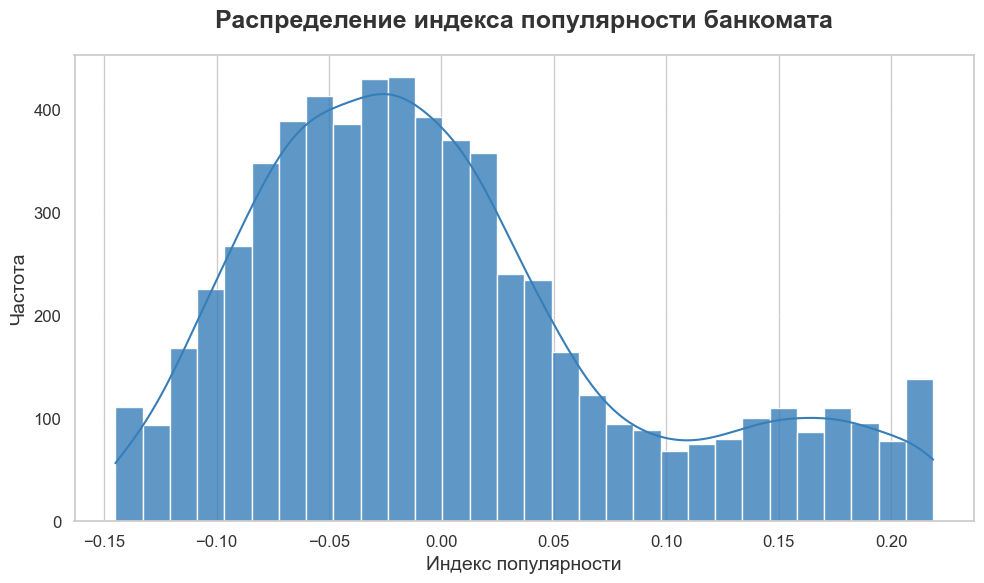

In [7]:
custom_plot(df,
            'target',
            title='Распределение индекса популярности банкомата',
            xlabel='Индекс популярности')

Из графика видно, что **распределение индекса популярности скошено влево**. То есть в выборке **преобладают банкоматы с низким индексом популярности**.

Посмотрим как распределяется целевая переменная по идентификатору банка:

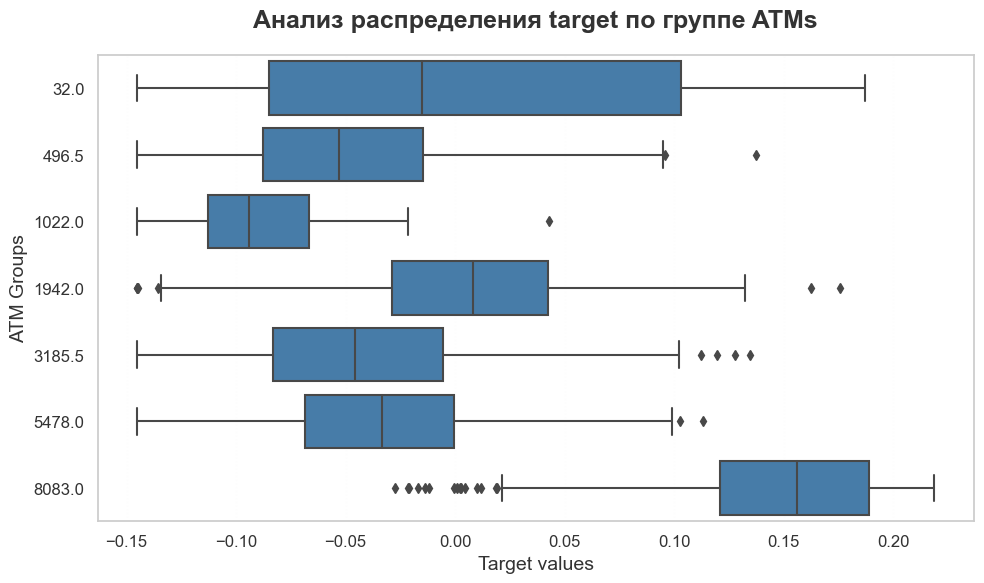

In [8]:
custom_boxplot(
    df,
    x_col="target",
    y_col="atm_group",
    orientation='h',
    title="Анализ распределения target по группе ATMs",
    xlabel="Target values",
    ylabel="ATM Groups"
)

Всего у нас 7 уникальных ATM групп, причем большинство банкоматов принадлежат группе 5478

In [5]:
len(df['atm_group'].unique())

7

In [6]:
df['atm_group'].value_counts()

5478.0    2662
1942.0    1160
8083.0    1050
496.5      616
3185.5     594
1022.0     136
32.0        43
Name: atm_group, dtype: int64

## Рассмотрим категориальные признаки

In [13]:
df.describe(include=[object]).T

,count,unique,top,freq
address,6261,5343,"HOROSHEVSKOE SH,V38 MOSKVA",7
address_rus,5957,4553,"улица Ватутина, 107, Новосибирск, Россия, 630024",8


Проанализируем по какой причине количество наиболее частых адресов на русском и английском языке отлично. Из таблицы ниже виждно, что для одного и того же русского адреса может отличаться его английское название

In [26]:
df[df['address_rus'] == 'улица Ватутина, 107, Новосибирск, Россия, 630024']

,Unnamed: 0,id,atm_group,address,address_rus,lat,long,target
2819,2819,1206.0,1942.0,107 VATUTINA STR NOVOSIBIRSK,"улица Ватутина, 107, Новосибирск, Россия, 630024",54.96408,82.936069,-0.008787
2998,2998,2821.0,3185.5,"VATUTINA,107 NOVOSIBIRSK","улица Ватутина, 107, Новосибирск, Россия, 630024",54.96408,82.936069,-0.015441
3451,3451,7796.0,5478.0,"D. 107, UL. VATUTINA NOVOSIBIRSK","улица Ватутина, 107, Новосибирск, Россия, 630024",54.96408,82.936069,-0.043290
3488,3488,8037.0,5478.0,"D. 107, UL. VATUTINA NOVOSIBIRSK","улица Ватутина, 107, Новосибирск, Россия, 630024",54.96408,82.936069,-0.011282
4135,4135,1365.0,1942.0,107 VATUTINA STR. NOVOSIBIRSK,"улица Ватутина, 107, Новосибирск, Россия, 630024",54.96408,82.936069,0.008347
4909,4909,3715.0,8083.0,"VATUTINA, 107 Novosibirsk","улица Ватутина, 107, Новосибирск, Россия, 630024",54.96408,82.936069,0.112024
4910,4910,3716.0,8083.0,"VATUTINA, 107 Novosibirsk","улица Ватутина, 107, Новосибирск, Россия, 630024",54.96408,82.936069,0.120748
4911,4911,3717.0,8083.0,"VATUTINA, 107 Novosibirsk","улица Ватутина, 107, Новосибирск, Россия, 630024",54.96408,82.936069,0.148339


## Построим распределние банкоматов на карте с их таргетом

In [ ]:
import pandas as pd
df = df.dropna()
df

,Unnamed: 0,id,atm_group,address,address_rus,lat,long,target
0,0,8526.0,32.0,"EMELYANOVA,34 Y-SAKHALINSK","улица А.О. Емельянова, 34, Южно-Сахалинск, Сах...",46.940995,142.738319,0.011500
1,1,8532.0,32.0,"KOMSOMOLSKAYA,259B Y.SAKHALINSK","Комсомольская улица, 259, Южно-Сахалинск, Саха...",46.937353,142.753348,0.029710
2,2,8533.0,32.0,"KOMMUN. PR., 32 YUZHNO SAKHAL","Коммунистический проспект, Южно-Сахалинск, Сах...",46.959413,142.741113,0.009540
3,3,8684.0,32.0,"LENINGRADSKIY PR.,76A MOSCOW","Ленинградский проспект, 76А, Москва, Россия, 1...",55.805827,37.515146,-0.094035
4,4,37.0,32.0,"GVARDEYSKAYA PL., 2 NORILSK","Гвардейская площадь, 2, Норильск, Красноярский...",69.343541,88.211228,0.079277
...,...,...,...,...,...,...,...,...
6256,6256,4402.0,8083.0,"FEDORA POPOVA, 14 Yakutsk","улица Федора Попова, 14, Якутск, Республика Са...",62.045259,129.748896,0.207916
6257,6257,4421.0,8083.0,"STROITELEY, 43 Novokuznetsk","проспект Строителей, 43, Новокузнецк, Кемеровс...",53.769459,87.117251,0.062220
6258,6258,4422.0,8083.0,"Rublevskoye sh, 62 Moskva","Рублёвское шоссе, 62, Москва, Россия, 121609",55.766212,37.380875,0.108743
6259,6259,4426.0,8083.0,"EFANOVA, 22 Zyryanskoye","улица Ефанова, 22, село Зырянское, Зырянский р...",56.838223,86.640829,0.148938


In [2]:
import plotly.express as px
fig = px.scatter_map(df, lat="lat", lon="long", color="target",
                  color_continuous_scale=px.colors.cyclical.IceFire, size_max=15, zoom=10)
fig.show()

## Выводы <a class="anchor" id="conclusion"></a>

Анализ показал следующее:
- большинство банкоматов сосредоточено в центральной части России
- самый большой таргет у банкоматов с ATM Group = 8083
- распределение индекса популярности скошено влево


Для дальнейших шагов нам необходимо будет добавить в датасет новые переменные. В частности используя функцию, которая подсчитывает количество объектов определенного типа в радиусе вокруг заданных координат.

Сделанные выводы мы будем использоваться в дальнейших шагах при построении ML моделей
